# Cell-cell comunication in a spatial context

This script focus on the usage of `CellphoneDB` to learn about cell-cell communication. This method is spatial-independent, while it can be split by different regions, `microenvironments`, defined a priory. We will compare later our observations at this scale with `SpatialCellChat`, which is spatial-aware.

## Prerequisites prior analysis: CellPhoneDB database
Prior to run, download the latest version of the database. In this version, it already includes the database zip file. 

```
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

## Check latest versions of the database. 
display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

## Download the database with the version of interest. 
from cellphonedb.utils import db_utils

cpdb_version = 'v5.0.0'
cpdb_target_dir = './cellphone_db_v5'
db_utils.download_database(cpdb_target_dir, cpdb_version)
```

## Load data and setup


We start with a anndata object, and export the metadata and normalized counts required as input for cellphoneDB. The metadata file requires 2 columns, the cell ID, labeled as `barcode_sample` and `cell_type`. We also need to ensure that the indexes of the metadata and counts match. 

In [18]:
## sbatch --mem=100G -p tier2q  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial

## LIBRARIES
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys
from scipy.sparse import csr_matrix
import anndata


import cellphonedb 

In [25]:
### Input files/directories for CellPhoneDB
cpdb_dir = './cellphone_db_v5/cellphonedb.zip'
w_dir = './CosMx/results/BreastCancer/CellPhoneDB/'
# os.mkdir(w_dir)

meta_tsv = os.path.join(w_dir, "BreastCancer_subset_metadata.tsv")
counts_h5ad = os.path.join(w_dir, "BreastCancer_subset_lognorm.h5ad")

## Load data and start preparing for CellPhoneDB
adata = sc.read_h5ad('./CosMx/results/BreastCancer/BreastCancer_subset_annotated.h5ad')


In [28]:
os.listdir('cellphone_db_v5')

['v5.0.0']

In [20]:
# ── Export lognorm layer as a standalone h5ad ─────────────────────────────────
adata_lognorm = sc.AnnData(
    X=adata.layers["lognorm"],
    obs=adata.obs,
    var=adata.var,
    obsm=adata.obsm,
    uns=adata.uns,
)
adata_lognorm.write_h5ad(counts_h5ad)

# ── Export cell metadata as TSV ───────────────────────────────────────────────
## Create the metadata table: the adata.obs.index is column 1, and renamed to barcode_sample, and final_annoation is the second column, renamed to cell_type
adata.obs['barcode_sample'] = adata.obs.index
adata.obs['cell_type'] = adata.obs['final_annotation']
metadata = adata.obs[['barcode_sample', 'cell_type']]

metadata.to_csv(meta_tsv, sep="\t")

print("Saved lognorm h5ad and metadata TSV.")

## Remove adata
del adata
del adata_lognorm

Saved lognorm h5ad and metadata TSV.


In [21]:
## Load metadata, and norm counts, and check that the cellIDs match

metadata = pd.read_csv(meta_tsv, sep="\t", index_col=0)
metadata.head()
## Add index as a new column - cellID
metadata['cellID'] = metadata.index

adata = anndata.read_h5ad(counts_h5ad)
adata.shape

list(adata.obs.index).sort() == list(metadata['cellID']).sort()

True

## Run CellPhoneDb - Base method.

In this case we are running CellPhoneDb in the most basic method first.

In [29]:
from cellphonedb.src.core.methods import cpdb_analysis_method

cpdb_results = cpdb_analysis_method.call(
    cpdb_file_path = cpdb_dir,           # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_tsv,           # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_h5ad,       # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',               # defines the gene annotation in counts matrix.
    score_interactions = True,                 # optional: whether to score interactions or not. 
    output_path = w_dir,                       # Path to save results    microenvs_file_path = None,
    separator = '|',                           # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    threads = 5,                               # number of threads to use in the analysis.
    threshold = 0.1,                           # defines the min % of cells expressing a gene for this to be employed in the analysis.
    result_precision = 3,                      # Sets the rounding for the mean values in significan_means.
    debug = False,                             # Saves all intermediate tables emplyed during the analysis in pkl format.
    output_suffix = None                       # Replaces the timestamp in the output files by a user defined string in the  (default: None)
)

[ ][CORE][31/03/26-21:44:02][INFO] [Non Statistical Method] Threshold:0.1 Precision:3
Reading user files...
The following user files were loaded successfully:
./CosMx/results/BreastCancer/CellPhoneDB/BreastCancer_subset_lognorm.h5ad
./CosMx/results/BreastCancer/CellPhoneDB/BreastCancer_subset_metadata.tsv


/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/site-packages/cellphonedb/src/core/models/complex/complex_helper.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  complex_to_protein_ids = complex_composition.groupby(COMPLEX_ID).apply(lambda x: x[PROTEIN_ID].values).to_dict()


[ ][CORE][31/03/26-21:44:08][INFO] Running Basic Analysis
[ ][CORE][31/03/26-21:44:08][INFO] Building results
[ ][CORE][31/03/26-21:44:09][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 6/6 [00:00<00:00, 16.85it/s]

[ ][CORE][31/03/26-21:44:09][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 6/6 [00:00<00:00, 49.98it/s]
/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/site-packages/cellphonedb/utils/scoring_utils.py:138: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matrix[index_name].replace(to_replace=id2name, inplace=True)


[ ][CORE][31/03/26-21:44:09][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 36/36 [00:27<00:00,  1.31it/s]


Saved means_result to ./CosMx/results/BreastCancer/CellPhoneDB/simple_analysis_means_result_03_31_2026_214437.txt
Saved deconvoluted to ./CosMx/results/BreastCancer/CellPhoneDB/simple_analysis_deconvoluted_03_31_2026_214437.txt
Saved deconvoluted_percents to ./CosMx/results/BreastCancer/CellPhoneDB/simple_analysis_deconvoluted_percents_03_31_2026_214437.txt
Saved interaction_scores to ./CosMx/results/BreastCancer/CellPhoneDB/simple_analysis_interaction_scores_03_31_2026_214437.txt


In [32]:
cpdb_results.keys()

dict_keys(['means_result', 'deconvoluted', 'deconvoluted_percents', 'interaction_scores'])

In [ ]:
## See the main results table. 
cpdb_results['means_result'].head()

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,Macrophages|LummHR-SCGB,Macrophages|Lumsec-prol,Macrophages|Macrophages,Macrophages|Plasma cells,Plasma cells|Endothelial cells,Plasma cells|Epithelial cells,Plasma cells|LummHR-SCGB,Plasma cells|Lumsec-prol,Plasma cells|Macrophages,Plasma cells|Plasma cells
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.043,0.042,0.033,0.035,0.044,0.032,0.038,0.037,0.028,0.029
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,...,0.088,0.087,0.078,0.080,0.048,0.036,0.042,0.041,0.032,0.033
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.069,0.069,0.059,0.061,0.045,0.034,0.039,0.038,0.029,0.031
3,CPI-SC0D3C12C3F,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,True,False,False,curated,...,0.038,0.037,0.028,0.029,0.047,0.036,0.041,0.040,0.031,0.033
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.202,0.201,0.192,0.193,0.116,0.104,0.110,0.109,0.100,0.101


In [ ]:
## Plots from CellPhoneDB


## Run CellPhoneDB Statistical

In [35]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_dir,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_tsv,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_h5ad,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
#    active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
#    microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = w_dir,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
./CosMx/results/BreastCancer/CellPhoneDB/BreastCancer_subset_lognorm.h5ad
./CosMx/results/BreastCancer/CellPhoneDB/BreastCancer_subset_metadata.tsv
[ ][CORE][31/03/26-22:20:34][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][31/03/26-22:20:34][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][31/03/26-22:20:35][INFO] Running Real Analysis
[ ][CORE][31/03/26-22:20:35][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [12:32<00:00,  1.33it/s]


[ ][CORE][31/03/26-22:33:08][INFO] Building Pvalues result
[ ][CORE][31/03/26-22:33:08][INFO] Building results
[ ][CORE][31/03/26-22:33:08][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 6/6 [00:00<00:00, 16.57it/s]

[ ][CORE][31/03/26-22:33:08][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 6/6 [00:00<00:00, 47.04it/s]


[ ][CORE][31/03/26-22:33:09][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 36/36 [00:27<00:00,  1.29it/s]


Saved deconvoluted to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_deconvoluted_03_31_2026_223337.txt
Saved deconvoluted_percents to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_deconvoluted_percents_03_31_2026_223337.txt
Saved means to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_means_03_31_2026_223337.txt
Saved pvalues to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_pvalues_03_31_2026_223337.txt
Saved significant_means to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_significant_means_03_31_2026_223337.txt
Saved interaction_scores to ./CosMx/results/BreastCancer/CellPhoneDB/statistical_analysis_interaction_scores_03_31_2026_223337.txt


### Results 

## Tables

**Means**

For those identified cell-cell interactions, the means values represent the mean of all the individual partner average expression. But if one of the mean values is 0, the meanwill be 0 too. 

**Significant Means**
Only keeps the means of relevant interactions per permutation test

CellPhoneDB uses a label-shuffling permutation test:

Observed mean: For a given L-R pair between cell type A and B, it calculates the mean expression of the ligand in A and the receptor in B (and vice versa).

Null distribution: Cell type labels are randomly shuffled across cells N times (default: 1000 permutations), and the mean is recalculated each time → builds a null distribution.

p-value: The fraction of permutations where the shuffled mean ≥ observed mean:



In [37]:
cpdb_results['means'].head(10)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,Macrophages|LummHR-SCGB,Macrophages|Lumsec-prol,Macrophages|Macrophages,Macrophages|Plasma cells,Plasma cells|Endothelial cells,Plasma cells|Epithelial cells,Plasma cells|LummHR-SCGB,Plasma cells|Lumsec-prol,Plasma cells|Macrophages,Plasma cells|Plasma cells
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.043,0.042,0.033,0.035,0.044,0.032,0.038,0.037,0.028,0.029
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,...,0.088,0.087,0.078,0.080,0.048,0.036,0.042,0.041,0.032,0.033
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.069,0.069,0.059,0.061,0.045,0.034,0.039,0.038,0.029,0.031
3,CPI-SC0D3C12C3F,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,True,False,False,curated,...,0.038,0.037,0.028,0.029,0.047,0.036,0.041,0.040,0.031,0.033
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.202,0.201,0.192,0.193,0.116,0.104,0.110,0.109,0.100,0.101
5,CPI-SC0FA343CEF,COL13A1_integrin_a2b1_complex,simple:Q5TAT6,complex:integrin_a2b1_complex,COL13A1,NaN,False,False,False,curated,...,0.036,0.035,0.026,0.027,0.050,0.038,0.044,0.043,0.034,0.035
6,CPI-SC0CCCF9A7F,COL14A1_integrin_a2b1_complex,simple:Q05707,complex:integrin_a2b1_complex,COL14A1,NaN,True,False,False,curated,...,0.039,0.038,0.029,0.030,0.042,0.031,0.036,0.035,0.026,0.028
7,CPI-SC0E85E1FB0,COL15A1_integrin_a2b1_complex,simple:P39059,complex:integrin_a2b1_complex,COL15A1,NaN,True,False,False,curated,...,0.089,0.088,0.079,0.080,0.061,0.049,0.055,0.054,0.045,0.046
8,CPI-SC0956F4A31,COL16A1_integrin_a2b1_complex,simple:Q07092,complex:integrin_a2b1_complex,COL16A1,NaN,True,False,False,curated,...,0.054,0.053,0.044,0.045,0.041,0.029,0.035,0.034,0.025,0.026
9,CPI-SC06EEEC092,COL17A1_integrin_a2b1_complex,simple:Q9UMD9,complex:integrin_a2b1_complex,COL17A1,NaN,True,False,False,curated,...,0.037,0.036,0.027,0.028,0.041,0.029,0.035,0.034,0.025,0.026


In [70]:
cpdb_results['significant_means'].head(10)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,Macrophages|LummHR-SCGB,Macrophages|Lumsec-prol,Macrophages|Macrophages,Macrophages|Plasma cells,Plasma cells|Endothelial cells,Plasma cells|Epithelial cells,Plasma cells|LummHR-SCGB,Plasma cells|Lumsec-prol,Plasma cells|Macrophages,Plasma cells|Plasma cells
1977,CPI-SC0B51DC960,PGF_FLT1_complex,simple:P49763,complex:FLT1_complex,PGF,NaN,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,CPI-SS07361522F,PGF_FLT1,simple:P49763,simple:P17948,PGF,FLT1,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,CPI-SC04FA882F7,COL10A1_integrin_a1b1_complex,simple:Q03692,complex:integrin_a1b1_complex,COL10A1,NaN,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980,CPI-SS01790830C,PGF_NRP1,simple:P49763,simple:O14786,PGF,NRP1,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2105,CPI-CC0010C54C6,atRetinoicAcid_byALDH1A1_RAreceptor_RARA,complex:atRetinoicAcid_byALDH1A1,complex:RAreceptor_RARA,NaN,NaN,True,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,CPI-SC0B4771D76,COL7A1_integrin_a10b1_complex,simple:Q02388,complex:integrin_a10b1_complex,COL7A1,NaN,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929,CPI-SS0837E9F59,JAG1_NOTCH4,simple:P78504,simple:Q99466,JAG1,NOTCH4,False,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928,CPI-SS0558101D1,DLL4_NOTCH4,simple:Q9NR61,simple:Q99466,DLL4,NOTCH4,False,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,CPI-SC039737584,COL18A1_integrin_a10b1_complex,simple:P39060,complex:integrin_a10b1_complex,COL18A1,NaN,True,False,False,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1907,CPI-SS0AFCA0602,DLL4_NOTCH1,simple:Q9NR61,simple:P46531,DLL4,NOTCH1,False,False,True,curated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
cpdb_results['interaction_scores'].head(10)

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,Macrophages|LummHR-SCGB,Macrophages|Lumsec-prol,Macrophages|Macrophages,Macrophages|Plasma cells,Plasma cells|Endothelial cells,Plasma cells|Epithelial cells,Plasma cells|LummHR-SCGB,Plasma cells|Lumsec-prol,Plasma cells|Macrophages,Plasma cells|Plasma cells
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CPI-SC0D3C12C3F,COL11A2_integrin_a2b1_complex,simple:P13942,complex:integrin_a2b1_complex,COL11A2,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,CPI-SC0FA343CEF,COL13A1_integrin_a2b1_complex,simple:Q5TAT6,complex:integrin_a2b1_complex,COL13A1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,CPI-SC0CCCF9A7F,COL14A1_integrin_a2b1_complex,simple:Q05707,complex:integrin_a2b1_complex,COL14A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,CPI-SC0E85E1FB0,COL15A1_integrin_a2b1_complex,simple:P39059,complex:integrin_a2b1_complex,COL15A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,CPI-SC0956F4A31,COL16A1_integrin_a2b1_complex,simple:Q07092,complex:integrin_a2b1_complex,COL16A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,CPI-SC06EEEC092,COL17A1_integrin_a2b1_complex,simple:Q9UMD9,complex:integrin_a2b1_complex,COL17A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## CellPhoneDB plotting with `ktplotspy`


CellPhoneDB provides a plotting function to visualize the significant interactions between two cell types. 

/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/scverse_spatial/lib/python3.12/site-packages


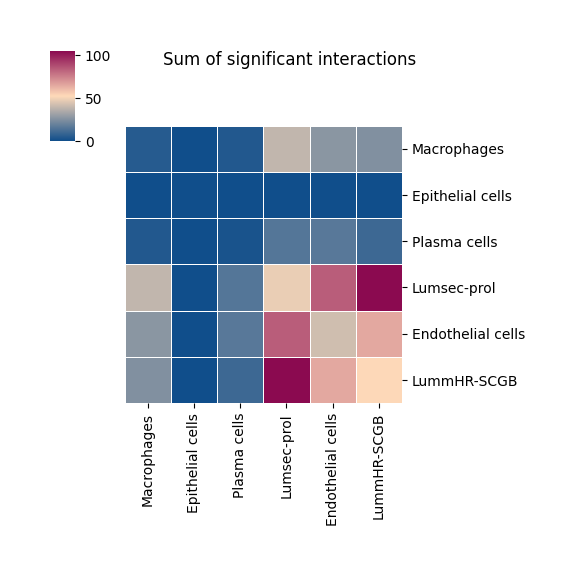

In [43]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

kpy.plot_cpdb_heatmap(pvals = cpdb_results['pvalues'],
                      degs_analysis = False,
                      figsize = (5, 5),
                      title = "Sum of significant interactions")

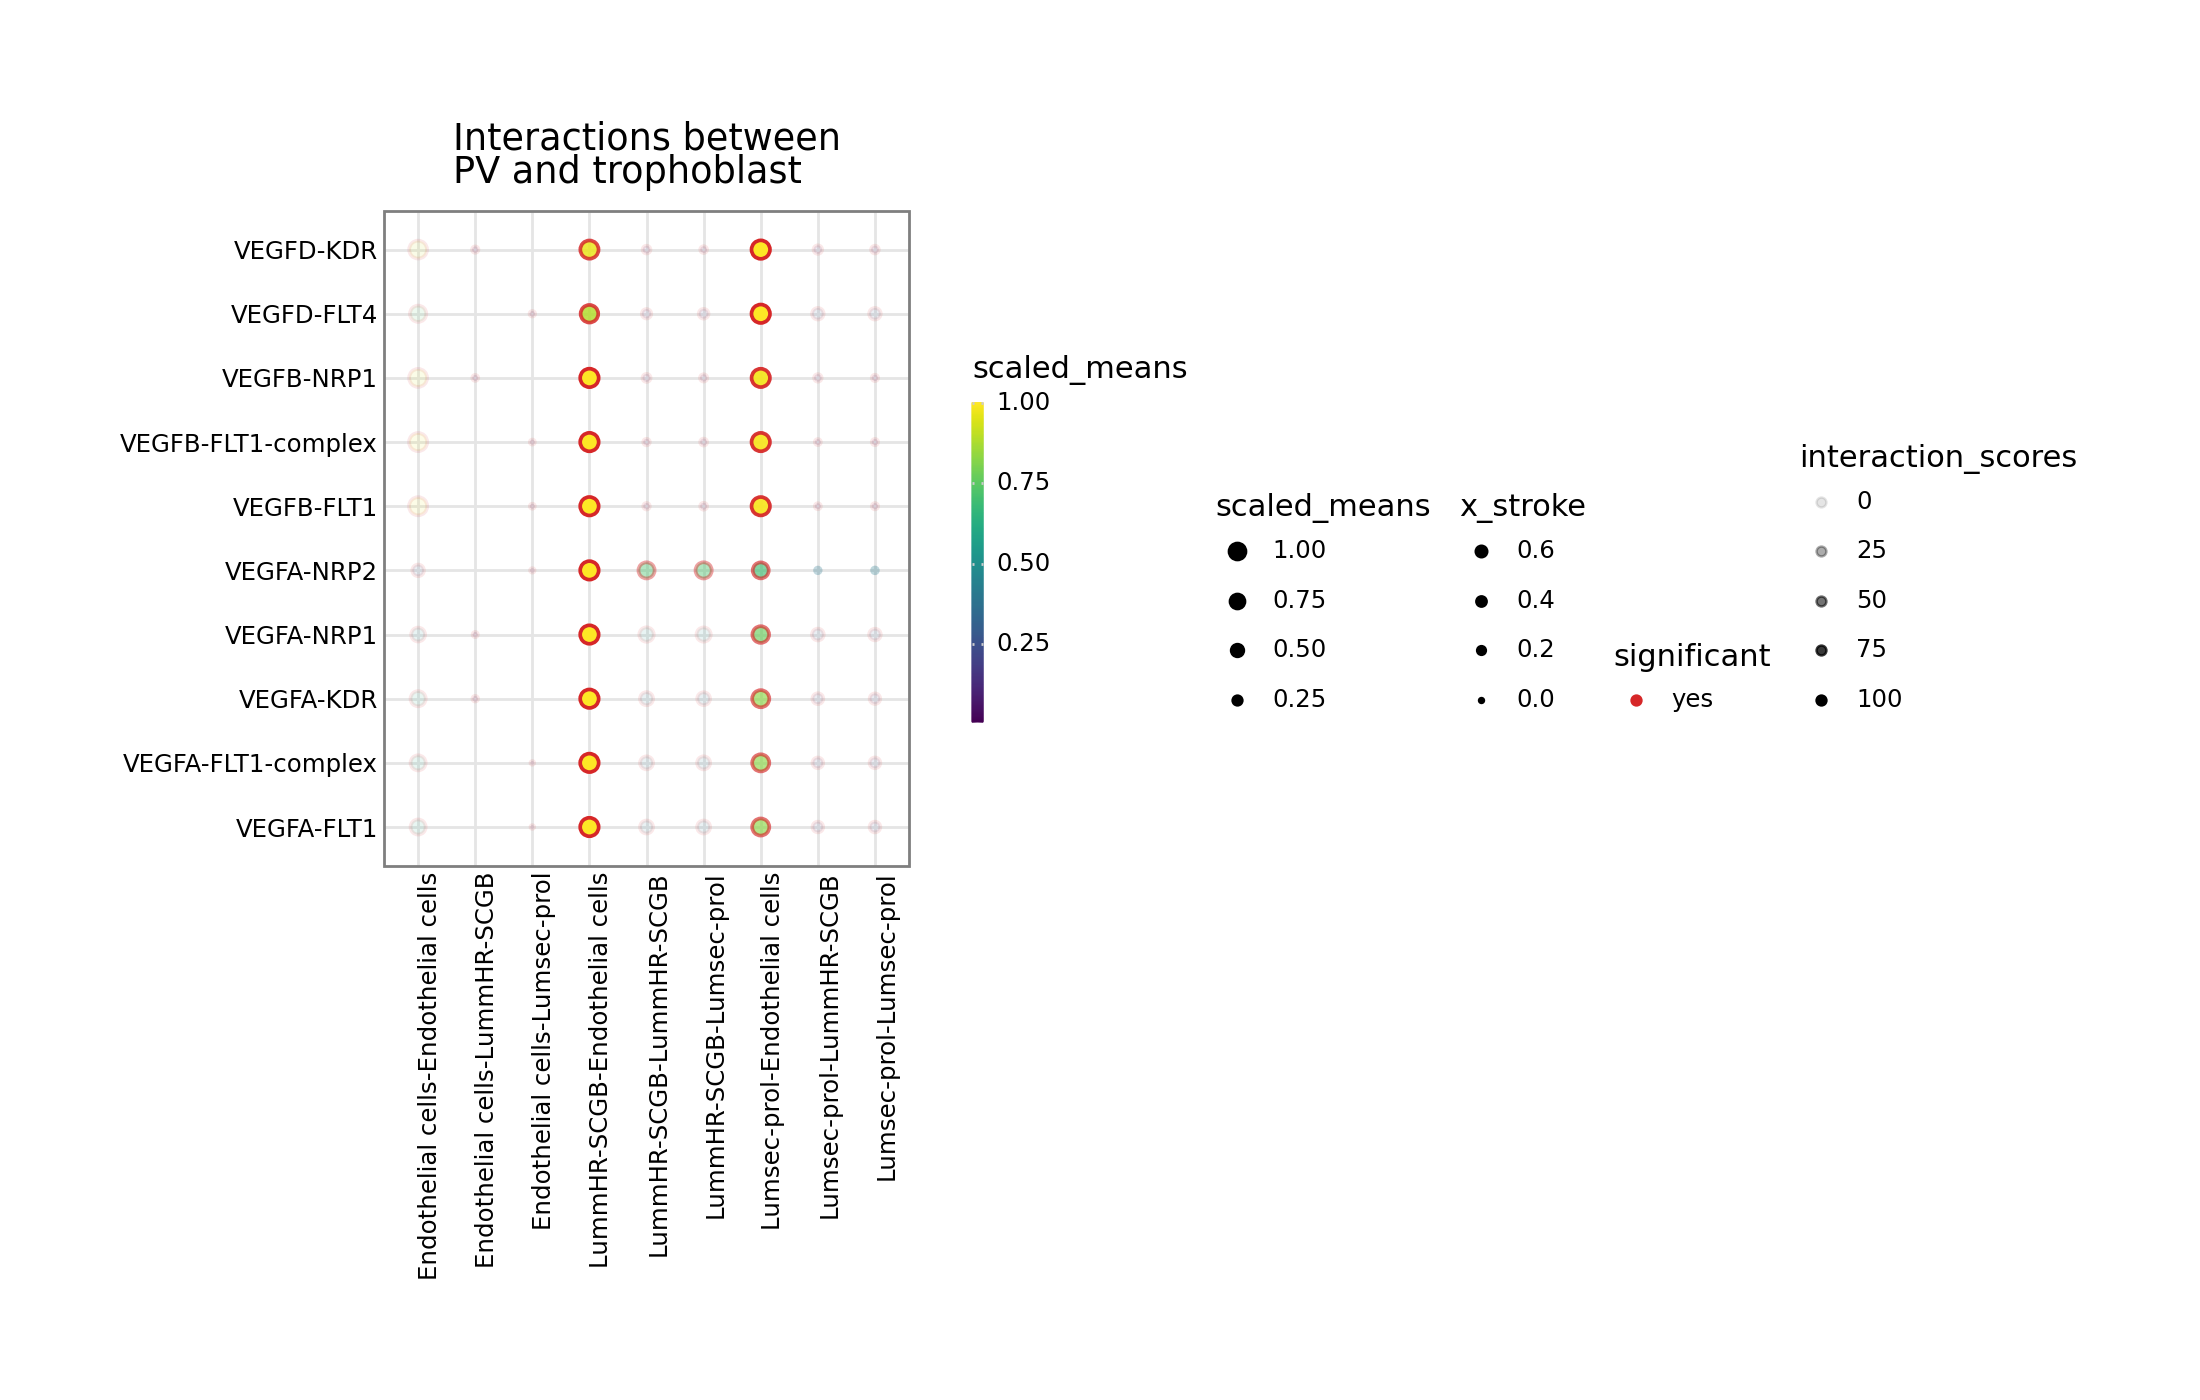

In [69]:
kpy.plot_cpdb(
    adata = adata,
    cell_type1 = "Endothelial cells|LummHR-SCGB|Lumsec-prol",
    cell_type2 = "Endothelial cells|LummHR-SCGB|Lumsec-prol",
    means = cpdb_results['means'],
    pvals = cpdb_results['pvalues'],
    celltype_key = "final_annotation",  ## Column in adata.obs that contains the cell type annotation used to run CellPhoneDB.
    genes = ["VEGFA", "VEGFD", "VEGFB", "VEGFC"], ## Filter to a specific set of genes. If None, will plot all significant interactions.
    figsize = (10, 6),
    title = "Interactions between\nPV and trophoblast",
    max_size = 3,
    highlight_size = 0.75,
    degs_analysis = False,
    standard_scale = True,
    interaction_scores = cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores = True
)